## Why Do We Need Root-Finding?

In the projectile motion project we found the launch angle that hits a target by simulating many trajectories over a range of angles and identifying which one came closest. This works, but it is slow: we have to run many full simulations and the precision is limited by how finely we sample the angle range.

A cleaner approach is to recognize that the problem is really asking us to solve an equation - *find the value of the unknown that makes some expression equal to zero* - and then use a dedicated **root-finding** algorithm to do it directly, with far fewer function evaluations and with precision we can dial up arbitrarily.

Given a function $f(x)$, we want to find $x^*$ such that $f(x^*) = 0$. The value $x^*$ is called a **root** or **zero** of $f$. Almost any equation can be rewritten in this form: if we want to solve $g(x) = c$, we just define $f(x) = g(x) - c$ and find its root.

## The Bisection Method

The bisection method is the simplest and most robust root-finding algorithm. It requires no derivative information and is guaranteed to converge, as long as we can supply an initial bracket $[a, b]$ that contains a root.

The method is based on the **Intermediate Value Theorem**: if $f$ is continuous and $f(a)$ and $f(b)$ have opposite signs, then $f$ must cross zero somewhere in the interval $[a, b]$.

### Step-by-step guide

#### 1. Choose an initial bracket $[a, b]$

Pick two points $a$ and $b$ such that $f(a)$ and $f(b)$ have **opposite signs**. Mathematically this is expressed as
$$f(a) \cdot f(b) < 0.$$
If this condition is not met, the method cannot guarantee a root is in the interval (there may be zero roots, or an even number of roots). The choice of $a$ and $b$ usually requires some physical insight - for instance, $R$ must be positive and less than the range in vacuum.

#### 2. Evaluate the midpoint and narrow the bracket

Compute the midpoint $m = (a + b)/2$ and evaluate $f(m)$.

- If $f(m)$ and $f(a)$ have the **same sign**, the root is in $[m, b]$, so we replace $a$ with $m$.
- If $f(m)$ and $f(a)$ have **opposite signs**, the root is in $[a, m]$, so we replace $b$ with $m$.

Either way, the bracket is cut in half. We can check which side the root is on with a single comparison:
$$f(m) \cdot f(a) > 0 \implies \text{same sign} \implies \text{root is in } [m, b].$$

#### 3. Repeat until converged

We keep halving the bracket until its width $b - a$ is smaller than a desired tolerance $dx$. After $n$ iterations the bracket width is $(b-a)/2^n$, so convergence is guaranteed and the number of iterations needed is $n = \log_2\!\bigl((b-a)/dx\bigr)$. For $dx = 10^{-10}$ and an initial bracket of width $\sim 1$, this is only about 33 iterations.

The root is then approximated as the midpoint of the final bracket.

### Pseudocode

```
bisection(f, a, b, dx):
    while b - a > dx:
        m = (a + b) / 2
        if f(m) * f(a) > 0:
            a = m        # root is in [m, b]
        else:
            b = m        # root is in [a, m]
    return (a + b) / 2
```

> **Tip:** Before calling `bisection()`, it is always a good idea to plot $f(x)$ over the region of interest to (1) confirm that a root exists, (2) identify a good bracket $[a,b]$, and (3) check whether there are multiple roots you might need to find separately.

### Implementation

Translate the pseudocode above into Python. Fill in each `???`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def bisection(f, a, b, dx=1e-10):
    """
    Find a root of f in the bracket [a, b] to within tolerance dx.
    Requires f(a) and f(b) to have opposite signs.
    """
    while b - a > dx:                      # keep looping while bracket is wider than dx
        m = (a + b) / 2                     # midpoint of current bracket
        if f(m) * f(a) > 0:
            a = m                 # f(m) same sign as f(a): root is in [m, b]
        else:
            b = m                 # f(m) opposite sign to f(a): root is in [a, m]
    return (a + b) / 2                      # best estimate: center of the final bracket

As a quick sanity check, let's find a zero of $\sin(x)$ near the origin. We know the answer is exactly 0.

In [3]:
bisection(np.sin, -1, 1)

-2.9103830456733704e-11

The result is not exactly zero because the tolerance `dx=1e-10` halts the search before reaching machine precision. But $\sim 10^{-11}$ is more than adequate for any physical application.

## Application: Projectile Motion

Recall our projectile with linear air drag. We simulated it numerically and swept over many launch angles to find the one that hits a target 20 m away. We can now solve this directly.

The analytical solution for the horizontal range $R$ of the projectile, given launch speed $v_0$ at angle $\theta$ and drag coefficient $b$, satisfies

$$\frac{R}{v_{x0}}\left(v_{z0} + \frac{g}{b}\right) + \frac{g}{b^2}\ln\!\left(1 - \frac{b\,R}{v_{x0}}\right) = 0,$$

where $v_{x0} = v_0\cos\theta$ and $v_{z0} = v_0\sin\theta$. This is a transcendental equation that cannot be solved for $\theta$ analytically. But if we define

$$f(\theta) = \frac{R_{\text{target}}}{v_{x0}}\left(v_{z0} + \frac{g}{b}\right) + \frac{g}{b^2}\ln\!\left(1 - \frac{b\,R_{\text{target}}}{v_{x0}}\right),$$

then $f(\theta) = 0$ at exactly the angles we're looking for. We can hand this directly to `bisection()`.

C:\Users\Bianca\AppData\Local\Temp\ipykernel_46892\1299232977.py:10: RuntimeWarning: invalid value encountered in log
  return (R_target / xvel0) * (zvel0 + (g/b)) + (g / b**2) * (np.log(1 - b * R_target / xvel0))                      # hint: plug xvel0, zvel0, R_target into the equation above


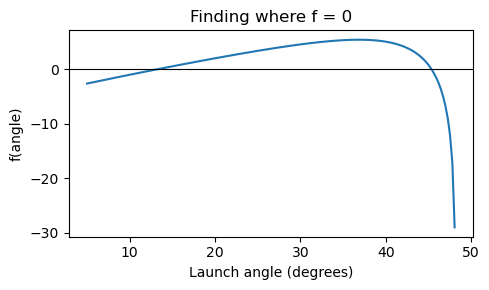

In [4]:
g = 10       # m/s^2
b = 1        # drag coefficient, 1/s
speed = 30   # launch speed, m/s
R_target = 20  # desired range, m

def f(angle_deg):
    angle = angle_deg / 180 * np.pi
    xvel0 = 30 * np.cos(angle)                     # hint: v0 * cos(angle)
    zvel0 = 30 * np.sin(angle)                     # hint: v0 * sin(angle)
    return (R_target / xvel0) * (zvel0 + (g/b)) + (g / b**2) * (np.log(1 - b * R_target / xvel0))                      # hint: plug xvel0, zvel0, R_target into the equation above

# Plot f(theta) to choose a good bracket
angles = np.linspace(5, 85, 300)
fig, ax = plt.subplots(1, figsize=(5, 3))
ax.plot(angles, [f(a) for a in angles])
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('Launch angle (degrees)')
ax.set_ylabel('f(angle)')
ax.set_title('Finding where f = 0')
plt.tight_layout()
plt.show()

In [5]:
result = bisection(f, 10, 20, dx=1e-3)   # choose a bracket based on the plot above
print(f'Launch angle: {result:.3f} degrees')

result = bisection(f, 40, 50, dx=1e-3)   # choose a bracket based on the plot above
print(f'Launch angle: {result:.3f} degrees')

Launch angle: 13.218 degrees
Launch angle: 45.370 degrees


Notice how much more direct this is compared to a parameter sweep: a single call to `bisection()` gives us the answer to any desired precision.

Note also that the plot shows $f$ crosses zero only once in the range $[5°, 85°]$ - if there were two crossings, we would need two separate `bisection()` calls with two separate brackets to find both roots.

## Looking Ahead: Newton-Raphson

In homework you will implement a second root-finding method called the **Newton-Raphson method**. Instead of bracketing, it uses the derivative $f'(x)$ to extrapolate directly to where the function crosses zero:

$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}.$$

Newton-Raphson converges much faster than bisection (quadratically rather than linearly), but it requires knowledge of $f'$ and a good initial guess - a poor guess can cause it to diverge or jump to the wrong root.

## Exercises

**Exercise 1.** Use `bisection()` to solve $\sin(x) = 0.1$. Rewrite the equation in the form $f(x) = 0$, plot $f$ to choose a bracket, and find the root. Check your answer.

**Exercise 2 (Newton-Raphson).** Implement the Newton-Raphson method:

```python
def newton(f, dfdx, x0, dx=1e-10):
    ...
```

where `dfdx` is a function that returns $f'(x)$ and `x0` is the initial guess. Use it to solve $\sin(x) = 0.1$ again and compare the number of iterations needed relative to bisection. What happens if you start from a poor initial guess?

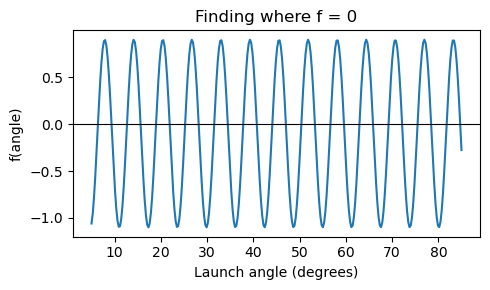

0.10016742118750699


In [9]:
# Exercise 1
def f(x):
    return np.sin(x) - 0.1    # hint: rearrange sin(x) = 0.1 so the right-hand side is 0

fig, ax = plt.subplots(1, figsize=(5, 3))
ax.plot(angles, [f(a) for a in angles])
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('Launch angle (degrees)')
ax.set_ylabel('f(angle)')
ax.set_title('Finding where f = 0')
plt.tight_layout()
plt.show()

result = bisection(f, 0, 1)   # hint: plot f first to pick a bracket
print(result)

In [ ]:
# Exercise 2
def newton(f, dfdx, x0, dx=1e-10):
    x = x0
    while abs(f(x) / dfdx(x)) >= dx:                    # hint: keep going until the step size |f/f'| is smaller than dx
        x = x - f(x) / dfdx(x)                          # hint: Newton-Raphson update rule
    return x

def dfdx(x):
    return np.cos(x)

result = newton(f, dfdx, 0)
print(result)

0.1001674211615598
